<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        30 Points
    </font>
</div>


In [ ]:
FULLNAME = 'YOUR NAME'
STD_ID = 'YOUR ID'

***Hossein Rezazadeh***

# Q3. License Plate Detection and Recognition (30 points)

## Introduction

In this assignment, we will build a two-stage license plate recognition system:

1. First stage: Detect license plates in an image (license plate detection / LPD)
2. Second stage: Recognize characters within the detected license plate (license plate recognition / LPR)

This approach is not explicitly an OCR (Optical Character Recognition), but it has some similarities with important differences. Unlike general OCR which often relies on sequence models (like RNNs or Transformers) to capture language context, license plates have a fixed format with predictable structure. This allows us to use multi-class classification or object detection models for it - first to locate plates, then to locate and classify individual characters.

## Background on YOLO (You Only Look Once)

### Evolution of Object Detection

Object detection has evolved significantly over the years:
- **Two-stage detectors** (like R-CNN family): First propose regions, then classify them
- **Single-stage detectors** (like YOLO and SSD): Predict bounding boxes and classes in a single forward pass

YOLO revolutionized object detection by framing it as a regression problem rather than a classification problem. Instead of generating region proposals and then classifying each region (a slow, two-stage process), YOLO divides the image into a grid and predicts bounding boxes and class probabilities directly in a single forward pass.

### YOLO Architecture

![YOLO Architecture](https://velog.velcdn.com/images/hunniee_j/post/cbd3888c-8b75-4325-988f-eadaded84232/image.JPG)

The basic YOLO approach:

1. **Grid Division**: Divide the image into an S×S grid
2. **Bounding Box Prediction**: Each grid cell predicts B bounding boxes, each with 5 parameters (x, y, w, h, confidence)
3. **Class Prediction**: Each grid cell also predicts class probabilities
4. **Non-Maximum Suppression**: Remove overlapping boxes with lower confidence scores

for a brief explanation of Object detection from RCNN to yolo version8 visit this [link](https://youtube.com/playlist?list=PL8VDJoEXIjppNvOzocFbRciZBrtSMi81v&si=qIh3VagQOzgWZ7Go)

the latest version of yolo is YOLO 12 and [here](https://docs.ultralytics.com/models/yolo12/) is Ultralytics documentation about it (all models of yolo family available in ultralytics has accessible documentation  [here](https://docs.ultralytics.com/models/) too.)


## Ultralytics Framework

Ultralytics is a Python library that makes it easy to train, test, and deploy YOLO models. Key features:

- **Easy to use API**: Simple Python API for training, validation, and inference
- **Pre-trained models**: Various pre-trained models of different sizes (nano to extra large)
- **Export options**: Export to various formats (ONNX, TFLite, CoreML, etc.)
- **Multi-task learning**: Support for object detection, segmentation, and pose estimation



## Assignment Tasks

In this assignment, you will:

1. Train a YOLO model for license plate detection on LPD dataset
2. Train a CNN model for license plate recognition within LPR license plates (7 digit + 1 letter classificaiton task)
3. Create an end-to-end pipeline that connects step 1 with 2
4. Evaluate the performance of your system on the test data


The dataset are available in [this](https://drive.google.com/drive/folders/1StRhbI28MaoiuXqA2rG5vGqKG5K2bMW6?usp=sharing) drive folder. let's dive into it!



In [ ]:
#Necessary installations

# %pip install -q ultralytics
# %pip install -q matplotlib opencv-python pyyaml

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# pip install ultralytics

  Using cached ultralytics-8.4.98-py3-none-any.whl.metadata (42 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached polars-1.42.1-py3-none-any.whl.metadata (10 kB)
  Using cached nvidia_ml_py-13.610.43-py3-none-any.whl.metadata (9.7 kB)
  Using cached ultralytics_thop-2.0.20-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.42.1-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
Using cached ultralytics-8.4.98-py3-none-any.whl (1.4 MB)
Using cached nvidia_ml_py-13.610.43-py3-none-any.whl (53 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
Using cached polars-1.42.1-py3-none-any.whl (837 kB)
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/52.7 MB ? eta -:--:--
   - -------------------------------------- 2.4/52.7 MB 7.5 MB/s eta 0:00:07
   -- --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
# pip install opencv-python pyyaml

Note: you may need to restart the kernel to use updated packages.


In [1]:
#imports

import os
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random
import pandas as pd
import pandas as pd
from PIL import Image
import torch
from torchvision import transforms
from IPython.display import display
import pandas as pd
import torch.utils.data as data
import torch
from tqdm import tqdm
import torch.optim as optim
import torch
import torch.nn as nn
from torchvision import models
import cv2


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
from pathlib import Path

root = Path(
    "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical"
)
root

WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical')

In [4]:
BASE_PATH = root / "data"

## 1. LPD - YOLO

1. first of all when you download the [dataset](https://drive.google.com/drive/folders/1StRhbI28MaoiuXqA2rG5vGqKG5K2bMW6?usp=sharing) from authors drive folder, unzip it in the `root/data` directory, it should have the following numbers 

In [ ]:
LPD_RELATIVE_PATH = 'IR-LPD'
LPD_DIR = f'{BASE_PATH}/{LPD_RELATIVE_PATH}'

images_dir = os.path.join(LPD_DIR, 'images')
labels_dir = os.path.join(LPD_DIR, 'labels')

In [ ]:
image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]

print(f"Dataset contains {len(image_files)} images and {len(label_files)} labels")


objects_count = 0
for label_file in [os.path.join(labels_dir, f) for f in label_files]:
    with open(label_file, 'r') as f:
        objects_count += len(f.readlines())

print(f"Total license plates in dataset: {objects_count}")
print(f"Average plates per image: {objects_count / max(1, len(image_files)):.2f}")

Dataset contains 6252 images and 6252 labels
Total license plates in dataset: 7257
Average plates per image: 1.16


<font color="orange">
1. What is the structure of YOLO's label files (`.txt`), and why are bounding box coordinates normalized? <br>
</font>
<font color =#475AAD>
Each YOLO label file is a text file where every line represents one object in the image. The format is:<br>
(x, y, w, h, confidence) <br>
All values are space-separated, and the bounding box coordinates are normalized to the range [0,1] relative to the image width and height. This makes the annotations independent of image resolution and allows the model to generalize across images of different sizes while improving training stability.<br>
</font>
<font color="orange">
<br>2. How does the YAML configuration file in YOLO define a dataset, and what role does the `nc` (number of classes) parameter play?  
</font><br>
<font color =#475AAD>
The YAML configuration file defines the dataset by specifying the paths to the training, validation, and test images, as well as the class names (names) and the number of classes (nc). YOLO reads this file to locate the dataset and understand its structure. The nc parameter specifies the total number of object classes that the model should detect.
</font><br>

<font color="orange">
<br>3. Why does YOLO use a grid system for predictions, and how does it handle multiple objects in a single grid cell?  
</font><br>
<font color =#475AAD>
YOLO divides the input image into a grid so that each grid cell is responsible for predicting objects whose centers fall inside it. This allows the model to process the entire image in a single forward pass, making object detection much faster than region proposal-based methods. In modern YOLO versions, each grid cell predicts multiple bounding boxes using anchor boxes, enabling it to detect multiple objects even within the same grid cell.
</font>


2. Pair each image with its corresponding label, then split the paired data into training and validation sets.

In [26]:
train_set_size = 0.8
val_set_size = 0.2

import random
random.seed(42)

paired_data = list(zip(image_files, label_files))
random.shuffle(paired_data)


shuffled_images, shuffled_labels = zip(*paired_data)

shuffled_images = list(shuffled_images)
shuffled_labels = list(shuffled_labels)



split = int(len(shuffled_images) * 0.8)

train_images = shuffled_images[:split]
val_images = shuffled_images[split:]

train_labels = shuffled_labels[:split]
val_labels = shuffled_labels[split:]

In [27]:
print(f"len of train = {len(train_images)}\t\t len of val = {len(val_labels)}")
print(f"len of train labels = {len(train_labels)}\t len of val labels = {len(val_labels)}")



len of train = 5001		 len of val = 1251
len of train labels = 5001	 len of val labels = 1251


In [34]:
for i in range(10):
    print(train_images[i], train_labels[i])

003126.jpg 003126.txt
005338.jpg 005338.txt
003946.jpg 003946.txt
004487.jpg 004487.txt
005015.jpg 005015.txt
003548.jpg 003548.txt
004266.jpg 004266.txt
002927.jpg 002927.txt
000478.jpg 000478.txt
000055.jpg 000055.txt


3. After splitting the dataset into training and validation sets, create the required subdirectories for the YOLO dataset structure. This directory layout will later be referenced by the `data.yaml` file.

In [5]:
print(os.getcwd())

e:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical


In [62]:
import os
import shutil

output_dir = "data/IR-LPD"

train_images_dir = os.path.join(output_dir, "images", "train")
val_images_dir   = os.path.join(output_dir, "images", "val")

train_labels_dir = os.path.join(output_dir, "labels", "train")
val_labels_dir   = os.path.join(output_dir, "labels", "val")

for folder in [
    train_images_dir,
    val_images_dir,
    train_labels_dir,
    val_labels_dir
]:
    os.makedirs(folder, exist_ok=True)

In [ ]:
images_dir = os.path.join(output_dir, "images")
labels_dir = os.path.join(output_dir, "labels")

# for training
for image_name in train_images:
    label_name = os.path.splitext(image_name)[0] + ".txt"

    image_source = os.path.join(images_dir, image_name)
    label_source = os.path.join(labels_dir, label_name)

    image_destination = os.path.join(train_images_dir, image_name)
    label_destination = os.path.join(train_labels_dir, label_name)

    shutil.move(image_source, image_destination)
    shutil.move(label_source, label_destination)

In [73]:
# for validation
for val_image_name in val_images:
    label_name = os.path.splitext(val_image_name)[0] + ".txt"

    val_image_source = os.path.join(images_dir, val_image_name)
    label_source = os.path.join(labels_dir, label_name)

    image_destination = os.path.join(val_images_dir, val_image_name)
    label_destination = os.path.join(val_labels_dir, label_name)

    shutil.move(val_image_source, image_destination)
    shutil.move(label_source, label_destination)

In [16]:
data_path = 'data/IR-LPD'
images_root = os.path.join(data_path, 'images')
labels_root = os.path.join(data_path, 'labels')

In [18]:
os.listdir(images_root)[0]

'train'

In [29]:
os.listdir(data_path)

['data.yaml', 'images', 'labels', 'plate_labels.csv']

In [31]:
images_subfolders = sorted(os.listdir(images_root))
labels_subfolders = sorted(os.listdir(labels_root))

print(f"""
Here's our dataset structure:

IR-LPD/
├── images/
│   ├── {images_subfolders[0]}/
│   └── {images_subfolders[1]}/
├── labels/
│   ├── {labels_subfolders[0]}/
│   └── {labels_subfolders[1]}/
└── data.yaml
""")


Here's our dataset structure:

IR-LPD/
├── images/
│   ├── train/
│   └── val/
├── labels/
│   ├── train/
│   └── val/
└── data.yaml



In [6]:
# you must create a yaml file there is just one class object detection and you must split the dataset into two parts (80%-20% for train and val)
# the executed result of cell is belong to train = val = all data for better understanding about the YOLO results.

import yaml
data = {
    "train": "images/train",
    "val": "images/val",
    "nc": 1,
    "names": ["plate"]
} 

output_dir = "data/IR-LPD"
YAML_PATH =  os.path.join(output_dir, 'data.yaml')

with open(YAML_PATH, "w") as f:
    yaml.dump(data, f)


In [7]:
VERSION = '11'
MODEL_SIZE = 'n'  # Options: n, s, m, l, x
EPOCHS = 20
IMGSZ = 640
BATCH = 16
DEVICE = '0'

<font color="orange">
Compare the architectural and functional advancements in YOLO versions 8 through 12. Specifically:  

1. **YOLOv8**:  
   - What was the motivation behind adopting an anchor-free design, and how did this impact training complexity and performance?  
   - How did the integration of CSPDarknet and PANet improve feature extraction and multi-scale detection compared to earlier versions?  

2. **YOLOv9 (Hypothetical/Unofficial)**:  
   - If YOLOv9 introduced dynamic label assignment, how does this differ from static assignment in YOLOv8, and what are the implications for model accuracy and convergence speed?  
   - What role might lightweight model variants (e.g., YOLOv9n) play in edge-device deployment, and how were they optimized for resource-constrained environments?  

3. **YOLOv10**:  
   - How did hybrid loss functions (e.g., combining CIoU and focal loss) enhance the training process, and what challenges in object detection were they designed to address?  
   - What advancements in model pruning and quantization were introduced, and how did these techniques reduce model size without compromising accuracy?  

4. **YOLOv11**:  
   - In what ways did self-calibrated convolutions improve feature extraction, and how do they compare to traditional convolutional layers in terms of computational efficiency and accuracy?  
   - How did the introduction of multi-task learning (e.g., joint object detection and segmentation) expand the capabilities of YOLOv11, and what new applications does this enable?  

5. **YOLOv12**:  
   - What benefits does the integration of transformer-based modules bring to YOLOv12, and how does this hybrid architecture balance the strengths of CNNs and transformers?  
   - How does uncertainty estimation in YOLOv12 improve the reliability of predictions, particularly in safety-critical applications like autonomous driving or medical imaging?  
   - Discuss the role of domain adaptation techniques in YOLOv12 and how they address challenges like dataset bias or environmental variability.  

Based on these advancements, which version would you recommend for this aplication, and why?  
</font>

# Comparison of YOLOv8 through YOLOv12

## 1. YOLOv8

### Anchor-free design

YOLOv8 replaced predefined anchor boxes with an anchor-free, decoupled detection head. In anchor-based detectors, anchor dimensions and aspect ratios must be selected or automatically tuned for the target dataset. This increases configuration complexity and may make the detector sensitive to differences between the training dataset and the anchor definitions.

The anchor-free design predicts object locations directly from feature-map points. This reduces the number of dataset-specific hyperparameters, simplifies model configuration and avoids the need to match each ground-truth box to several predefined anchor shapes. Its decoupled head also uses separate branches for classification and bounding-box regression, allowing each task to learn more specialized features. YOLOv8 additionally uses Distribution Focal Loss for more precise box-coordinate regression. ([Ultralytics Docs][1])

The main consequences are:

* simpler dataset preparation and model configuration;
* fewer anchor-related hyperparameters;
* improved adaptability to objects with unusual aspect ratios;
* a better accuracy–speed balance than earlier anchor-based Ultralytics models.

### CSP-based backbone and PAN/FPN feature fusion

The question describes the backbone as CSPDarknet, although YOLOv8 more specifically uses the **C2f block**, a CSP-inspired structure, rather than simply reusing the earlier CSPDarknet backbone. C2f preserves multiple gradient paths and concatenates intermediate feature maps, helping information and gradients flow through the network efficiently. ([Ultralytics Docs][1])

Its neck combines top-down FPN-style fusion with bottom-up PAN-style aggregation:

* the top-down path transfers high-level semantic information to higher-resolution feature maps;
* the bottom-up path transfers localization details back toward deeper feature maps;
* detection is then performed at multiple feature-map scales.

This arrangement helps detect both large objects and small objects such as distant or low-resolution licence plates. Compared with an FPN-only design, PAN-style bottom-up aggregation provides stronger localization information across scales.

---

## 2. YOLOv9

### Important correction

YOLOv9 is **not hypothetical or unofficial**. It was introduced in the paper *YOLOv9: Learning What You Want to Learn Using Programmable Gradient Information*. Its central innovations are:

* **Programmable Gradient Information**, or PGI;
* **Generalized Efficient Layer Aggregation Network**, or GELAN. ([arXiv][2])

Dynamic label assignment is not presented as the defining innovation of the official YOLOv9 paper.

### Dynamic versus static label assignment

If a hypothetical YOLOv9 implementation used dynamic label assignment, the difference would be as follows.

With static assignment, positive training samples are selected using relatively fixed geometric rules, such as predefined centre regions, IoU thresholds or fixed top-k criteria. The assignment is mostly determined by the relationship between the ground-truth box and candidate prediction locations.

With dynamic assignment, the model’s current predictions influence which candidates become positive examples. Classification confidence, localization quality and IoU may be combined into a matching cost. As training progresses, the selected positives can therefore change.

Potential benefits include:

* better matching between predictions and ground-truth objects;
* fewer low-quality positive samples;
* improved recall and localization;
* potentially faster convergence after the early training stage.

However, early predictions are initially unreliable. A poorly designed dynamic assigner may therefore make training unstable or add computational cost. It should not automatically be assumed to converge faster in every dataset.

For the official YOLOv9, PGI instead addresses information loss in deep networks by providing more reliable gradient information during training. GELAN provides an efficient architecture with strong parameter utilization across small and large model sizes. ([arXiv][2])

### Lightweight variants and edge deployment

The official YOLOv9 repository includes lightweight variants such as **YOLOv9-T**, rather than naming the smallest official model YOLOv9n. YOLOv9-T uses approximately 2 million parameters and 7.7 GFLOPs at a 640-pixel input resolution, demonstrating the role of smaller variants in resource-constrained deployment. ([GitHub][3])

Lightweight models are valuable on edge devices because they:

* require less memory;
* perform fewer floating-point operations;
* reduce inference latency;
* consume less power;
* are easier to export to TensorRT or similar runtimes.

The main YOLOv9 architectural efficiency comes from GELAN and its effective gradient-path design, not simply from replacing all layers with depthwise convolutions. The original paper explicitly notes that GELAN achieves strong parameter utilization using conventional convolution operations. ([arXiv][2])

---

## 3. YOLOv10

### Important correction

YOLOv10’s defining advancement is not a newly introduced combination of CIoU and focal loss. Its main contribution is **end-to-end, NMS-free object detection using consistent dual assignments**, together with an efficiency–accuracy-driven architecture design. ([arXiv][4])

### Hybrid loss functions

In general, a hybrid detection loss can combine several objectives:

* a localization loss such as IoU, GIoU, DIoU or CIoU;
* a classification loss such as binary cross-entropy or focal loss;
* optionally, a distribution-based bounding-box regression loss.

CIoU considers overlap, centre distance and aspect-ratio consistency. It helps boxes converge toward the correct position and shape. Focal loss reduces the contribution of easy background samples and emphasizes difficult or misclassified examples.

Such a combination can address:

* foreground–background class imbalance;
* difficult examples;
* inaccurate box localization;
* slow box-shape convergence.

However, this is a general explanation of hybrid detection losses, not the principal novelty claimed by YOLOv10.

YOLOv10 instead uses **one-to-many assignment during training** to provide rich supervision and **one-to-one assignment** to produce one final prediction per object. The consistent matching metric between the two branches enables the one-to-one branch to retain good accuracy while eliminating NMS at inference. ([arXiv][4])

### Pruning and quantization

The official YOLOv10 work does not primarily introduce a new pruning or quantization algorithm. It reduces computation through architectural redesign, including lightweight classification heads, spatial-channel decoupled downsampling, rank-guided block design and larger-kernel components where they provide an accuracy benefit. This produces lower parameter counts and latency without treating pruning as the main contribution. ([arXiv][4])

Pruning and quantization can still be applied after training:

* **pruning** removes unimportant weights, channels or blocks;
* **FP16 quantization** stores and computes values with 16-bit precision;
* **INT8 quantization** can reduce memory and increase throughput further, but normally requires representative calibration data;
* quantization-aware training can reduce the accuracy loss associated with INT8 conversion.

The official repository directly supports export to ONNX and TensorRT, including FP16 TensorRT export, but INT8 conversion is a separate deployment procedure rather than a core YOLOv10 architectural innovation. ([GitHub][5])

---

## 4. YOLO11

### Important correction

Ultralytics calls the model **YOLO11**, not YOLOv11. Its documented architectural changes include:

* C3k2 blocks replacing many C2f blocks;
* a C2PSA attention module after SPPF;
* a lighter classification branch using depthwise-separable convolutions.

Self-calibrated convolution is not documented as the defining YOLO11 mechanism. ([Ultralytics Docs][1])

### Feature extraction

The C3k2 module builds on the C2f design but can use configurable C3k internal blocks. This improves the reuse and fusion of intermediate features.

C2PSA introduces spatial attention, helping the network emphasize informative image regions and long-range relationships. Meanwhile, depthwise-separable convolutions in the classification branch reduce computation by separating spatial filtering from channel mixing.

Compared with ordinary full convolutions:

* attention can provide more context-aware features;
* depthwise-separable convolutions reduce parameters and FLOPs;
* the overall design can improve accuracy without proportionally increasing computation.

Ultralytics reports that YOLO11m obtains higher COCO mAP than YOLOv8m while using 22% fewer parameters. ([GitHub][6])

### Multi-task capabilities

YOLO11 supports several computer-vision tasks within the same ecosystem:

* object detection;
* instance segmentation;
* image classification;
* pose estimation;
* oriented bounding-box detection.

This does not necessarily mean that one default YOLO11 checkpoint performs all tasks simultaneously. In most cases, separate model heads and checkpoints are trained for each task. Nevertheless, sharing the same framework and related backbone designs makes it much easier to build multi-task systems. ([Ultralytics Docs][7])

For example, an automatic licence-plate recognition system could combine:

1. licence-plate detection;
2. plate segmentation or rectification;
3. character recognition;
4. vehicle detection or tracking.

Other applications include autonomous driving, medical-image analysis, industrial inspection, human-pose analysis and aerial-image detection.

---

## 5. YOLOv12

### Transformer and attention-based modules

YOLOv12 is a research model introduced as an **attention-centric real-time detector**. It was designed to obtain the stronger global modelling ability of attention while retaining the low latency traditionally associated with CNN-based YOLO models. ([arXiv][8])

CNNs are especially effective at:

* extracting local textures and edges;
* exploiting spatial locality;
* running efficiently on standard vision hardware.

Attention mechanisms are especially useful for:

* modelling relationships between distant regions;
* capturing global context;
* distinguishing objects from visually confusing backgrounds;
* associating separated object parts.

YOLOv12 balances these strengths through efficient attention-oriented blocks rather than replacing the entire network with a large, conventional vision transformer. Its published results report that YOLOv12-N achieved 40.6% COCO mAP with 1.64 ms latency on a T4 GPU, exceeding the reported accuracy of similarly sized YOLOv10-N and YOLO11-N at comparable speed. ([arXiv][8])

### Uncertainty estimation

Uncertainty estimation is **not identified as a central built-in contribution of the official YOLOv12 paper**. Therefore, it would be inaccurate to claim that standard YOLOv12 inherently provides calibrated uncertainty estimates.

Nevertheless, uncertainty estimation could be added to a YOLOv12-based system using techniques such as:

* model ensembles;
* Monte Carlo dropout;
* test-time augmentation;
* Bayesian approximations;
* calibration methods;
* separate prediction-quality or uncertainty heads.

In safety-critical systems, uncertainty can help distinguish between:

* a confident detection;
* an ambiguous object;
* an out-of-distribution image;
* a prediction that should be referred to a human or another safety mechanism.

For autonomous driving, an uncertain pedestrian detection may trigger a more conservative action. In medical imaging, an uncertain lesion prediction can be flagged for specialist review. However, confidence scores are not automatically equivalent to calibrated uncertainty.

### Domain adaptation

Domain adaptation is also not presented as a defining built-in YOLOv12 feature. It is an additional training strategy that could be applied to YOLOv12 or other detectors.

It attempts to reduce the gap between a source domain and a target domain. Examples include:

* daytime training images versus nighttime deployment;
* clear-weather data versus rain, fog or snow;
* one type of camera versus another;
* synthetic data versus real images;
* licence plates from one country versus another.

Possible methods include:

* target-domain fine-tuning;
* style-transfer augmentation;
* adversarial feature alignment;
* self-training with pseudo-labels;
* domain-specific normalization;
* uncertainty-aware pseudo-label filtering.

These methods can reduce dataset bias and environmental sensitivity, but they require an explicit adaptation pipeline and should not be attributed to the standard YOLOv12 architecture itself.

---

# Summary of the actual main advancements

| Model   | Principal advancement                                                                              |
| ------- | -------------------------------------------------------------------------------------------------- |
| YOLOv8  | Anchor-free decoupled head, C2f blocks, DFL regression and strong multi-task Ultralytics ecosystem |
| YOLOv9  | Programmable Gradient Information and GELAN                                                        |
| YOLOv10 | Consistent dual assignment and end-to-end NMS-free detection                                       |
| YOLO11  | C3k2, C2PSA attention, lighter classification head and broad task support                          |
| YOLOv12 | Attention-centric architecture designed to combine global modelling with real-time speed           |

[1]: https://docs.ultralytics.com/guides/yolo-architecture?utm_source=chatgpt.com "YOLO Architecture Explained | Ultralytics"
[2]: https://arxiv.org/abs/2402.13616?utm_source=chatgpt.com "YOLOv9: Learning What You Want to Learn Using Programmable Gradient Information"
[3]: https://github.com/wongkinyiu/yolov9?utm_source=chatgpt.com "GitHub - WongKinYiu/yolov9: Implementation of paper - YOLOv9: Learning What You Want to Learn Using Programmable Gradient Information · GitHub"
[4]: https://arxiv.org/abs/2405.14458?utm_source=chatgpt.com "YOLOv10: Real-Time End-to-End Object Detection"
[5]: https://github.com/THU-MIG/yolov10?utm_source=chatgpt.com "GitHub - THU-MIG/yolov10: YOLOv10: Real-Time End-to-End Object Detection [NeurIPS 2024] · GitHub"
[6]: https://github.com/ultralytics/ultralytics/blob/main/docs/en/models/yolo11.md?utm_source=chatgpt.com "ultralytics/docs/en/models/yolo11.md at main · ultralytics/ultralytics · GitHub"
[7]: https://docs.ultralytics.com/models/yolo11?utm_source=chatgpt.com "Ultralytics YOLO11 | Ultralytics"
[8]: https://arxiv.org/abs/2502.12524?utm_source=chatgpt.com "YOLOv12: Attention-Centric Real-Time Object Detectors"

In [ ]:
LPD_model = 'yolo11n'
from ultralytics import YOLO

# Create a new YOLO model from scratch
model = YOLO("yolo11n.yaml")

# Train the model using the 'data.yaml' dataset for number of epochs
results = model.train(data="data.yaml", epochs=EPOCHS)

# Evaluate the model's performance on the validation set
results = model.val()

# Perform object detection on an image using the model
results = model("https://ultralytics.com/images/bus.jpg")

# Export the model to ONNX format
success = model.export(format="onnx")

In [6]:
os.getcwd()

'e:\\Study\\Deep Learning\\4 - Exercises\\0 - Source books\\3 - Dr. Soleymani\\Myself\\2 - HW2\\Practical'

In [ ]:
print(f"Starting YOLO{VERSION}{MODEL_SIZE} training for {EPOCHS} epochs...")

from ultralytics import YOLO

LPD_model = YOLO("yolo11n.yaml")

# Train the model using the 'data.yaml' dataset for number of epochs
results = LPD_model.train(data=YAML_PATH, epochs=EPOCHS, project=os.path.join("Results"), name="YOLO_runs")

print("Training complete! Model saved to Results/YOLO_runs folder.")

Starting YOLO11n training for 20 epochs...
New https://pypi.org/project/ultralytics/8.4.100 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.98  Python-3.12.8 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/IR-LPD\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

In [12]:
os.getcwd()

'e:\\Study\\Deep Learning\\4 - Exercises\\0 - Source books\\3 - Dr. Soleymani\\Myself\\2 - HW2\\Practical'

In [21]:
results = model(img_path)

results[0].show()


image 1/1 e:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical\data\IR-LPD\images\val\006120.jpg: 640x480 1 plate, 67.8ms
Speed: 4.8ms preprocess, 67.8ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 480)


Testing model on validation images...

image 1/1 e:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical\data\IR-LPD\images\val\005355.jpg: 480x640 1 plate, 69.9ms
Speed: 4.8ms preprocess, 69.9ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)


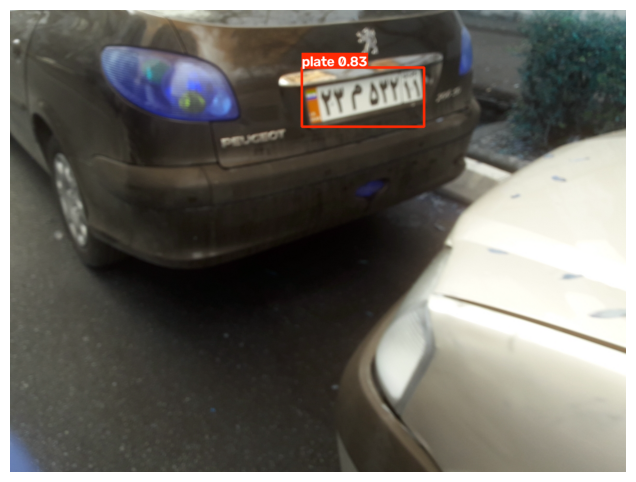


image 1/1 e:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical\data\IR-LPD\images\val\002600.jpg: 640x480 2 plates, 54.0ms
Speed: 6.1ms preprocess, 54.0ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 480)


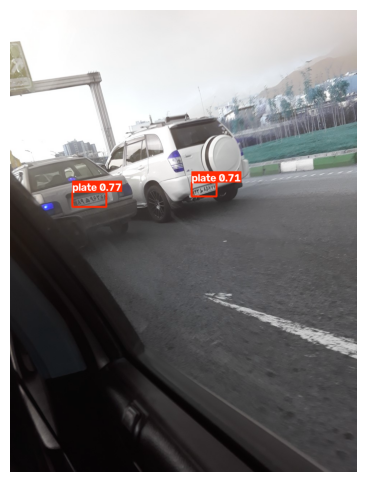


image 1/1 e:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical\data\IR-LPD\images\val\000635.jpg: 640x384 1 plate, 41.0ms
Speed: 4.5ms preprocess, 41.0ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 384)


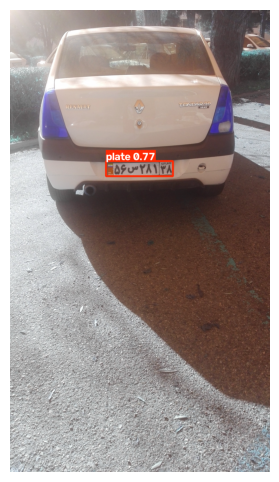


image 1/1 e:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical\data\IR-LPD\images\val\005609.jpg: 416x640 1 plate, 75.7ms
Speed: 4.5ms preprocess, 75.7ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 640)


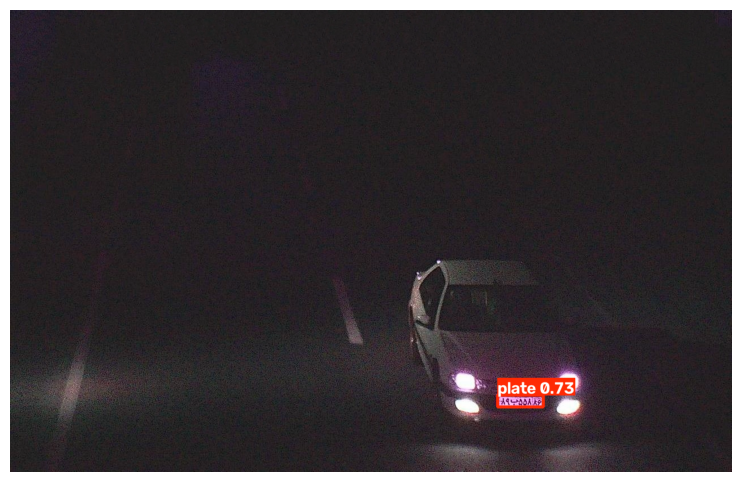


image 1/1 e:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical\data\IR-LPD\images\val\000167.jpg: 384x640 1 plate, 44.9ms
Speed: 3.7ms preprocess, 44.9ms inference, 8.6ms postprocess per image at shape (1, 3, 384, 640)


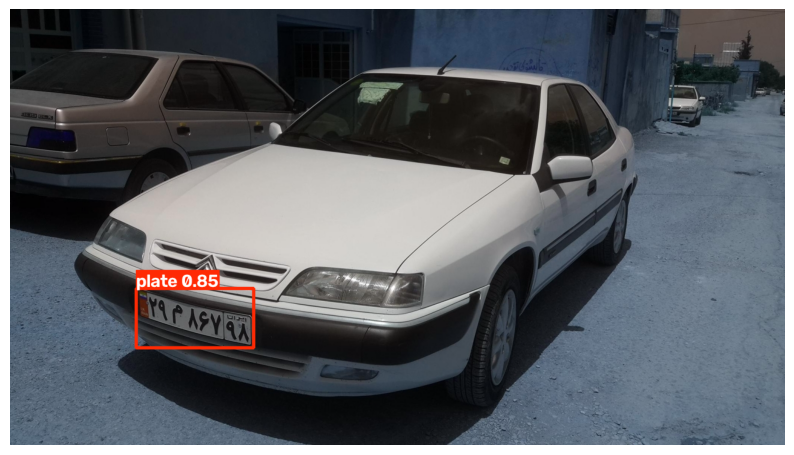

In [ ]:
print("Testing model on validation images...")

image_dir = "data/IR-LPD/images/val"

#loading model
model = YOLO(
    "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/Results/Models/best.pt")

%matplotlib inline

image_files = [
    f for f in os.listdir(image_dir)
    if f.endswith((".jpg", ".jpeg", ".png"))
]

for img_file in random.sample(image_files, 5):

    img_path = os.path.join(image_dir, img_file)

    results = model(img_path)

    annotated = results[0].plot()

    plt.figure(figsize=(10, 6))
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()

### 2. LPR - CNN

In [10]:
LPR_RELATIVE_PATH = 'IR-LPR'

df = pd.read_csv(f'{BASE_PATH}/{LPR_RELATIVE_PATH}/valid_samples.csv')
df = df.sample(n=22000, random_state=42)    #  22000// 24561 = 0.898

In [12]:
digit_vocabulary = "0123456789"
persian_letters = "آ ب پ ت ث ج چ ح خ د ذ ر ز ژ س ش ص ض ط ظ ع غ ف ق ک گ ل م ن و ه ی".split()


digit_to_idx = {char: idx for idx, char in enumerate(digit_vocabulary)}
letter_to_idx = {char: idx for idx, char in enumerate(persian_letters)}
idx_to_digit = {idx: char for idx, char in enumerate(digit_vocabulary)}
idx_to_letter = {idx: char for idx, char in enumerate(persian_letters)}


persian_to_english_digits = {
    '۰': '0', '۱': '1', '۲': '2', '۳': '3', '۴': '4',
    '۵': '5', '۶': '6', '۷': '7', '۸': '8', '۹': '9'
}

persian_letter_normalization = {
    "الف": "آ",
    "ا" : "آ",
    "ژ (معلولین و جانبازان)": "ژ",
    "ه‍" : "ه"
}



def translate(label):

    first_two_digits = ''.join([persian_to_english_digits.get(char, char) for char in label[:2]]) # 35 - -----
    persian_letter = label[2] # -- ب -----
    remaining_digits = ''.join([persian_to_english_digits.get(char, char) for char in label[3:]]) # -- - 41267
    return first_two_digits + persian_letter + remaining_digits # example: 3541267ب


def preprocess_sample(image_path, label , full_transform=True, log=False, dir_path = BASE_PATH , relative_path= f'{LPR_RELATIVE_PATH}/detections', language='en'):

    if language == 'fa' :
      label = translate(label)

    elif language != 'en':
          raise Exception('Un-supported language!') # we are doing Irans LPR

    path = f'{dir_path}/{relative_path}'

    train_transform = transforms.Compose([
        transforms.Resize((64, 256)),       # uses interpolation internally

        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.1
            )
        ], p=0.5),

        transforms.RandomAffine(
            degrees=3,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        
    ])

    test_transform = transforms.Compose([
        transforms.Resize((64, 256)),       # uses interpolation internally

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    transform = train_transform if full_transform else test_transform
    image = Image.open(f'{path}/{image_path}').convert("RGB")
    image = transform(image)


    for key, value in persian_letter_normalization.items():
        label = label.replace(key, value)



    if log:
      print(label)

      for i , c in enumerate(label):
        if c in persian_letters:
          c = '*'
        print(f"{i}:{c}", end=' | ')

      print()


    digits = [digit_to_idx[char] for char in label if char.isdigit()]
    letter = letter_to_idx[label[2]]

    return image, digits, letter

In [9]:
df.columns.tolist()

['image_path', 'label']

In [50]:
BASE_PATH

WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data')

In [38]:
class PLPRDataset(data.Dataset):
    def __init__(self, df , split='train',dir_path=BASE_PATH,
                 relative_path = f'{LPR_RELATIVE_PATH}/detections', language='en'):
        self.df = df.reset_index(drop=True)
        self.full_transform = True if split == 'train' else False   # True/train = Data augmentation
        self.dir_path = dir_path
        self.relative_path = relative_path
        self.language = language

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image, digits, letter = preprocess_sample(
            image_path=row["image_path"],
            label=row["label"],
            full_transform=self.full_transform,
            dir_path=self.dir_path,
            relative_path=self.relative_path,
            language=self.language
        )

        digit_labels = torch.tensor(
            digits,
            dtype=torch.long
        )

        letter_label = torch.tensor(
            letter,
            dtype=torch.long
        )

        return image, digit_labels, letter_label

In [11]:
print(df.columns.tolist())
print(df.iloc[0])
print(type(df.iloc[0]["label"]))

['image_path', 'label']
image_path    15320.jpg
label          91و46621
Name: 15319, dtype: object
<class 'str'>


In [12]:
dataset = PLPRDataset(df)

image, digit_label, letter_label = dataset[0]

print(image.shape)
print(digit_label, digit_label.shape, digit_label.dtype)
print(letter_label, letter_label.shape, letter_label.dtype)

torch.Size([3, 64, 256])
tensor([9, 1, 4, 6, 6, 2, 1]) torch.Size([7]) torch.int64
tensor(29) torch.Size([]) torch.int64


In [7]:
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

In [ ]:
class FCNPLPRModel(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0"):
        super().__init__()

        num_digits = 7
        num_digit_classes = len(digit_vocabulary)        # 10
        num_letter_classes = len(persian_letters)        # 32

        if backbone_name == "efficientnet_b0":
            backbone = models.efficientnet_b0(
                weights=EfficientNet_B0_Weights.DEFAULT
            )
        else:
            raise ValueError(
                f"Unsupported backbone: {backbone_name}"
            )

        # EfficientNet-B0 feature vectors
        num_features = backbone.classifier[1].in_features

        # removing the Imagenet classifier head
        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.shared_layer = nn.Sequential(
            nn.Linear(num_features, 512),   # 512 is an example, you can try anything else
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # now turning to our dataset classifier for digits
        self.digit_head = nn.Linear(
            512,
            num_digits * num_digit_classes
        )

        # now turning to our dataset classifier for farsi charracters
        self.letter_head = nn.Linear(
            512,
            num_letter_classes
        )

        self.num_digits = num_digits
        self.num_digit_classes = num_digit_classes

    def forward(self, x):
        features = self.backbone(x)

        features = self.shared_layer(features)

        digit_outputs = self.digit_head(features)

        digit_outputs = digit_outputs.view(
            x.size(0),
            self.num_digits,
            self.num_digit_classes
        )

        letter_output = self.letter_head(features)

        return digit_outputs, letter_output

In [57]:
learning_rate = 4e-4
batch_size = 32

In [16]:
dataset = PLPRDataset(df)
dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        #persistent_workers=True # False if GPU isn't accessibile
)

In [17]:
LPR_model = FCNPLPRModel().to(device)
digit_criterion = nn.CrossEntropyLoss()
letter_criterion = nn.CrossEntropyLoss()

In [18]:
optimizer = optim.AdamW(LPR_model.parameters(), lr=learning_rate)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    threshold=0.05,
    threshold_mode='rel'
    # verbose=True          # for old versions (not ours) of torch, verbose=True
)

In [78]:
def decode_predictions(digit_outputs, letter_output):
    digit_predictions = torch.argmax(digit_outputs, dim=2)  # [batch_size, 7]
    batch_size = digit_predictions.size(0)

    digits = []
    for b in range(batch_size):  # Iterate over batch
        sample_digits = []
        for i in range(7):  # Iterate over 7 digits
            try:
                sample_digits.append(idx_to_digit[digit_predictions[b][i].item()])
            except KeyError as e:
                print(f"KeyError: {e} (digit_predictions[{b}][{i}] = {digit_predictions[b][i].item()})")
                sample_digits.append("?")  # Use a placeholder for invalid indices
        digits.append(sample_digits)

    letter_prediction = torch.argmax(letter_output, dim=1)  # [batch_size]
    letters = []
    for b in range(batch_size):
        try:
            letters.append(idx_to_letter[letter_prediction[b].item()])
        except KeyError as e:
            print(f"KeyError: {e} (letter_prediction[{b}] = {letter_prediction[b].item()})")
            letters.append("?")  # Use a placeholder for invalid indices

    labels = []
    for b in range(batch_size):
        label = "".join(digits[b][:2]) + letters[b] + "".join(digits[b][2:])
        labels.append(label)

    return labels



def evaluate_misclassification(gt, pred):
    assert len(gt) == len(pred), "GT and Pred must have the same length."

    # Collect misclassified characters
    misclassified = []
    char_error_count = 0

    for i, (gt_char, pred_char) in enumerate(zip(gt, pred)):
        if gt_char != pred_char:
            misclassified.append(f"{gt_char} with {pred_char} at pos {i}")
            char_error_count += 1

    # Format the output
    misclassified_str = " , ".join(misclassified) if misclassified else "None"
    result = (f"GT: {gt} | Pred: {pred} | "
              f"Misclassified: {misclassified_str} | "
              f"Char error count: {char_error_count}")

    return result , char_error_count





def calculate_accuracy(model, df, device, dir_path=BASE_PATH, relative_path=f'{LPR_RELATIVE_PATH}/detections', language='en', log=False , cer = False):
    model.eval()
    FP= []
    CE = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df)):
            image_path = row["image_path"]
            label = row["label"]
            try:
                image, true_digits, true_letter = preprocess_sample(image_path, label, full_transform=False, dir_path=dir_path, relative_path=relative_path, language=language)

            except Exception as e:
                print(f"Error processing {image_path}: {e}")
                continue
            true_label = "".join([digit_vocabulary[d] for d in true_digits[:2]]) \
                         + persian_letters[true_letter] \
                         + "".join([digit_vocabulary[d] for d in true_digits[2:]])
            image = image.unsqueeze(0).to(device)
            digit_outputs, letter_output = model(image)

            predicted_labels = decode_predictions(digit_outputs, letter_output)

            if predicted_labels[0] == true_label:
                correct += 1
            elif log:
                report , char_error_count = evaluate_misclassification(true_label,predicted_labels[0])
                CE += char_error_count
                FP.append(report)
            total += 1


    accuracy = correct / total * 100

    if cer:
        print(f'CER: {100* CE/(8*df.shape[0]): .4f}%')

    if log:
         for false_positive in FP:
            print(false_positive)



    return accuracy

In [48]:
full_df = pd.read_csv(f'{BASE_PATH}/IR-LPR/valid_samples.csv')
test_df = full_df.loc[~full_df.index.isin(df.index)]    # ~ in NOT


In [21]:
images, digit_labels, letter_labels = next(iter(dataloader))

print("Images:", images.shape)
print("Digit labels:", digit_labels.shape)
print("Letter labels:", letter_labels.shape)
print("Digit dtype:", digit_labels.dtype)
print("Letter dtype:", letter_labels.dtype)

Images: torch.Size([32, 3, 64, 256])
Digit labels: torch.Size([32, 7])
Letter labels: torch.Size([32])
Digit dtype: torch.int64
Letter dtype: torch.int64


In [ ]:
best_accuracy = 85.0
optimal_weights = None
num_epochs = 10
BASE_PATH = root / "Results" 

for epoch in range(num_epochs):
    LPR_model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for images, digit_targets, letter_targets in progress_bar:
        images = images.to(device)
        digit_targets = digit_targets.to(device)
        letter_targets = letter_targets.to(device)

        # Forward pass
        digit_outputs, letter_output = LPR_model(images)

        digit_loss = 0
        for i in range(7):
            digit_loss += digit_criterion(digit_outputs[:, i, :], digit_targets[:, i])
        letter_loss = letter_criterion(letter_output, letter_targets)
        loss = digit_loss + letter_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

    LPR_model.eval()
    accuracy = calculate_accuracy(
        LPR_model,
        test_df,
        device,
        relative_path= f'{LPR_RELATIVE_PATH}/detections',
        language='en'
    )
    print(f"Accuracy after Epoch {epoch+1}: {accuracy:.2f}%")

    scheduler.step(accuracy)

if accuracy > best_accuracy:
    best_accuracy = accuracy

    optimal_weights = {
        key: value.detach().cpu().clone()
        for key, value in LPR_model.state_dict().items()
    }

    print(f"New best accuracy: {best_accuracy:.2f}%. Saving model weights.")


    model_dir = os.path.join(BASE_PATH, "Models")
    os.makedirs(model_dir, exist_ok=True)

    torch.save(
        optimal_weights,
        os.path.join(model_dir, "PLPR-CNN.pth")
    )

if optimal_weights is not None:
    LPR_model.load_state_dict(optimal_weights)
    print("Loaded optimal weights into the model.")

Epoch 1/10, Average Loss: 0.9324


100%|██████████| 2561/2561 [00:48<00:00, 53.09it/s]


Accuracy after Epoch 1: 91.41%


Epoch 2/10, Average Loss: 0.7557


100%|██████████| 2561/2561 [00:49<00:00, 51.63it/s]


...

100%|██████████| 2561/2561 [00:49<00:00, 51.60it/s]


Accuracy after Epoch 9: 93.52%


Epoch 10/10, Average Loss: 0.2062


100%|██████████| 2561/2561 [00:55<00:00, 46.17it/s]


Accuracy after Epoch 10: 93.75%
New best accuracy: 93.75%. Saving model weights.
Loaded optimal weights into the model.


In [ ]:
import os

model_path = os.path.join(BASE_PATH, "Models", "PLPR-CNN.pth")   # just checking

print(os.path.exists(model_path))
print(model_path)

True
E:\Study\Deep Learning\4 - Exercises\0 - Source books\3 - Dr. Soleymani\Myself\2 - HW2\Practical\data\model\PLPR-CNN.pth


In [ ]:
# Calculate accuracy
accuracy = calculate_accuracy(LPR_model, test_df, device, cer=True, log=True)
print(f"Accuracy: {accuracy:.2f}%")

100%|██████████| 2561/2561 [00:54<00:00, 47.30it/s]

CER:  1.0933%
GT: 51ژ66416 | Pred: 51ع66416 | Misclassified: ژ with ع at pos 2 | Char error count: 1
GT: 57ژ46711 | Pred: 57ط46711 | Misclassified: ژ with ط at pos 2 | Char error count: 1
GT: 81ع27744 | Pred: 81ع37744 | Misclassified: 2 with 3 at pos 3 | Char error count: 1
GT: 52ع35813 | Pred: 52ع35812 | Misclassified: 3 with 2 at pos 7 | Char error count: 1
GT: 81ت74133 | Pred: 89ت74133 | Misclassified: 1 with 9 at pos 1 | Char error count: 1
GT: 45ت87733 | Pred: 45ت87722 | Misclassified: 3 with 2 at pos 6 , 3 with 2 at pos 7 | Char error count: 2
GT: 21ت13611 | Pred: 21ت13622 | Misclassified: 1 with 2 at pos 6 , 1 with 2 at pos 7 | Char error count: 2
GT: 91ی36388 | Pred: 61ی36388 | Misclassified: 9 with 6 at pos 0 | Char error count: 1
GT: 93ی57410 | Pred: 92ی57410 | Misclassified: 3 with 2 at pos 1 | Char error count: 1
GT: 74ه62255 | Pred: 74ه64255 | Misclassified: 2 with 4 at pos 4 | Char error count: 1
GT: 87ه59611 | Pred: 83ه59611 | Misclassified: 7 with 3 at pos 1 | Char erro

### 3. E2E LPDR

load the models from part 2 and 3, build a class named E2E_LPDR and plot report the metrics (accuracy and cer) for the test dataset (20% of LPD that has Splitted in section 1 ). you must also plot some samples with predicted bounding box and label too.


note that each picture might have multiple plates but in this test data for simplicity all samples just have a single plate exists in it.
plot some samples from your pipeline (predicted bb from an image + predicted label of it)


### 1- first of all loading models

In [5]:
# defining the reuling models pathes
Results_path = "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/Results/Models"

In [97]:
from ultralytics import YOLO

# loaing only weights for YOLO model (not Models)

LPD_WEIGHTS = os.path.join(Results_path, "best.pt")

OCR_WEIGHTS = os.path.join(Results_path, "PLPR-CNN.pth")

# defining Models
# Plate detector
LPD_model = YOLO(LPD_WEIGHTS)

# loaing only weights
# OCR model
LPR_model = FCNPLPRModel(backbone_name="efficientnet_b0")   
LPR_model.load_state_dict(
    torch.load(OCR_WEIGHTS, map_location=device)
)

LPR_model = LPR_model.to(device)
LPR_model.eval()

FCNPLPRModel(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale

### 2- Loading validation 

In [94]:
validation_path = "data/IR-LPD"

validation_img_path = root / "data" / "IR-LPD" / "images" / "val"
validation_label_path = root / "data" / "IR-LPD" / "labels" / "val"

In [95]:
validation_images = sorted([
    image_path
    for image_path in validation_img_path.iterdir()
    if (
        image_path.is_file()
        and image_path.suffix.lower()
    )
])

print(f"Number of validation images: {len(validation_images)}")

Number of validation images: 1251


In [96]:
print("Images directory exists:", validation_img_path.exists())
print("Labels directory exists:", validation_label_path.exists())
print("Number of validation images:", len(validation_images))

Images directory exists: True
Labels directory exists: True
Number of validation images: 1251


### 3- giving it to YOLO for recognition and cropping 

In [106]:
def detect_and_crop_plates(
    model,
    image_paths,
    output_dir,
    confidence_threshold=0.75,
    device=None
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    detections = []

    for image_path in tqdm(
        image_paths,
        desc="Detecting and cropping plates"
    ):
        image_path = Path(image_path)

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as error:
            print(f"Could not open {image_path}: {error}")
            continue

        results = model.predict(
            source=str(image_path),
            conf=confidence_threshold,
            device=device,
            verbose=False
        )

        result = results[0]

        if result.boxes is None or len(result.boxes) == 0:
            detections.append({
                "source_image": image_path,
                "detected": False,
                "crop_path": None,
                "confidence": None,
                "bbox": None
            })
            continue

        image_width, image_height = image.size

        for detection_index, box in enumerate(result.boxes):
            x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()
            confidence = float(box.conf[0].cpu())


            x1 = max(0, int(round(x1)))
            y1 = max(0, int(round(y1)))
            x2 = min(image_width, int(round(x2)))
            y2 = min(image_height, int(round(y2)))


            if x2 <= x1 or y2 <= y1:
                print(
                    f"Invalid bounding box for {image_path.name}: "
                    f"{x1, y1, x2, y2}"
                )
                continue

            plate_crop = image.crop((x1, y1, x2, y2))

            crop_filename = (
                f"{image_path.stem}_plate_{detection_index}"
                f"{image_path.suffix.lower()}"
            )

            crop_path = output_dir / crop_filename
            plate_crop.save(crop_path)

            detections.append({
                "source_image": image_path,
                "detected": True,
                "crop_path": crop_path,
                "confidence": confidence,
                "bbox": [x1, y1, x2, y2]
            })

    return detections

In [124]:
VAL_CROPS_DIR = root / "Results" / "validation_plate_crops" #creating a subfolder for cropped imgaes with YOLO model 

validation_detections = detect_and_crop_plates(
    model=LPD_model,
    image_paths=validation_images,
    output_dir=VAL_CROPS_DIR,
    confidence_threshold=0.2,
    device=0
)

Detecting and cropping plates:   0%|          | 0/1251 [00:00<?, ?it/s]

In [125]:
import math
import random
import matplotlib.pyplot as plt


def show_plate_crops(
    detections,
    num_samples=8,
    random_state=42
):
    valid_detections = [
        item
        for item in detections
        if (
            item["detected"]
            and item["crop_path"] is not None
        )
    ]

    if not valid_detections:
        print("No plate crops were found.")
        return

    num_samples = min(
        num_samples,
        len(valid_detections)
    )

    rng = random.Random(random_state)
    selected = rng.sample(
        valid_detections,
        num_samples
    )

    columns = 2
    rows = math.ceil(num_samples / columns)

    plt.figure(figsize=(14, rows * 3))

    for index, sample in enumerate(
        selected,
        start=1
    ):
        crop = Image.open(
            sample["crop_path"]
        ).convert("RGB")

        plt.subplot(rows, columns, index)
        plt.imshow(crop)
        plt.axis("off")

        plt.title(
            f"{sample['source_image'].name}\n"
            f"Confidence: {sample['confidence']:.3f}"
        )

    plt.tight_layout()
    plt.show()

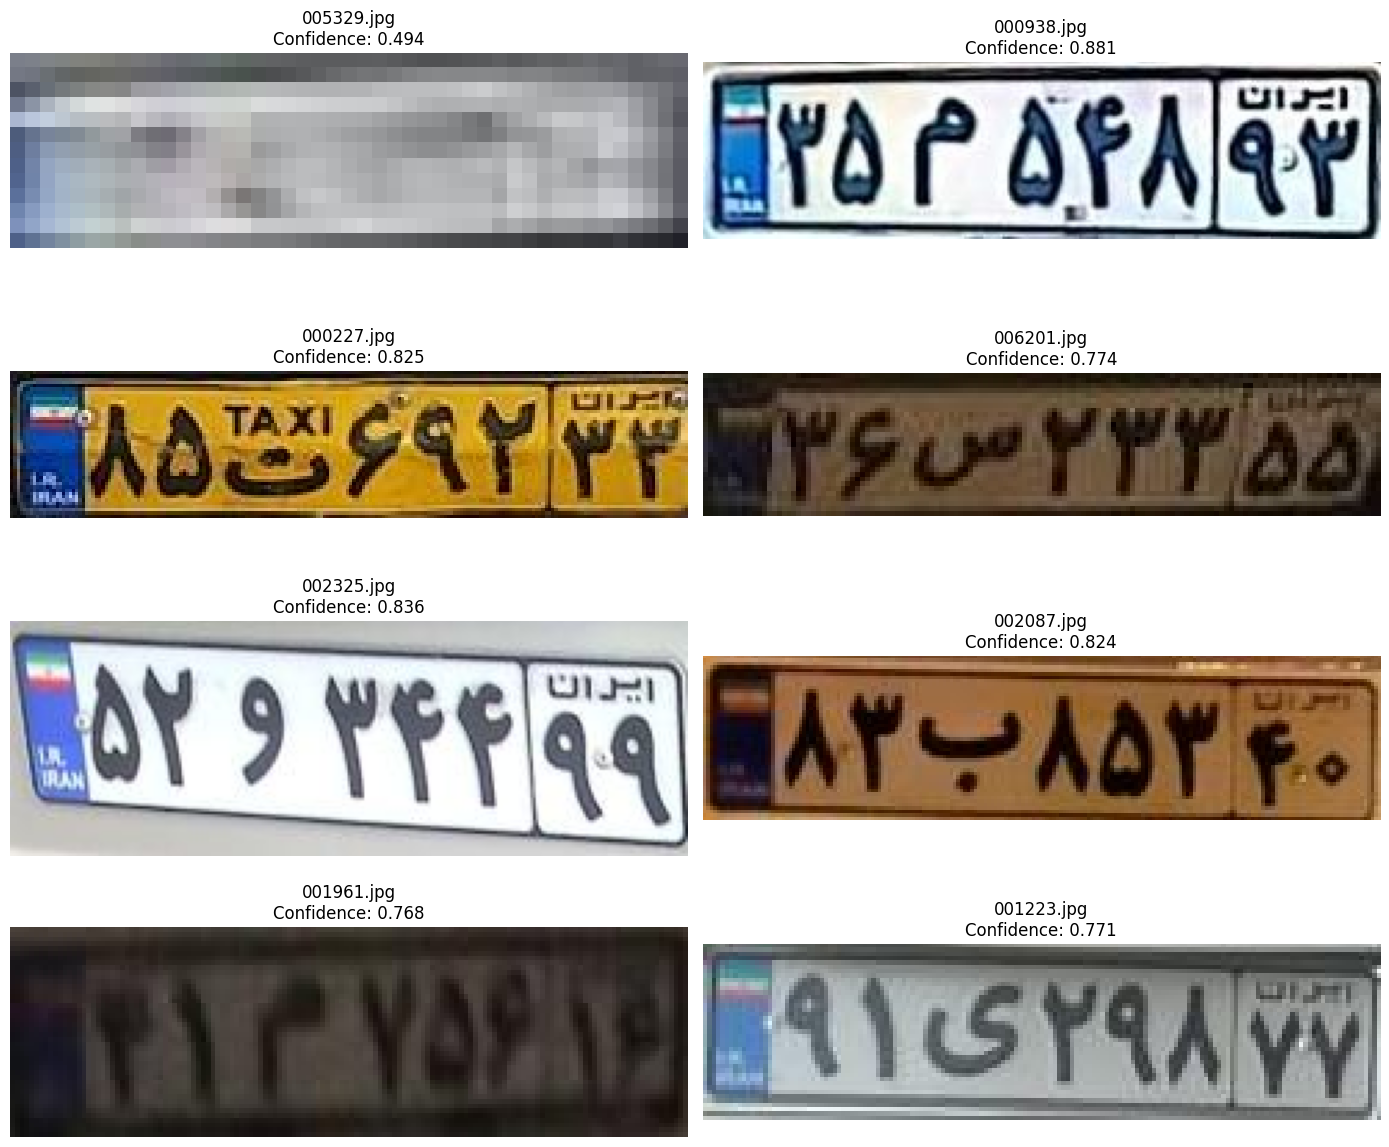

In [126]:
show_plate_crops(
    validation_detections,
    num_samples=8
)

### 4- now using our previous OCR

In [127]:
from torchvision import transforms
from PIL import Image
import torch

# our same transformation
ocr_transform = transforms.Compose([
    transforms.Resize((64, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def predict_plate_text(model, crop_path, device):
    model.eval()

    image = Image.open(crop_path).convert("RGB")
    image = ocr_transform(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        digit_outputs, letter_output = model(image)

    prediction = decode_predictions(
        digit_outputs,
        letter_output
    )[0]

    return prediction

In [128]:
ocr_results = []

for detection in validation_detections:

    if not detection["detected"]:
        continue

    prediction = predict_plate_text(
        model=LPR_model,
        crop_path=detection["crop_path"],
        device=device
    )

    ocr_results.append({
        "image_path": detection["source_image"],
        "crop_path": detection["crop_path"],
        "prediction": prediction,
        "confidence": detection["confidence"]
    })

In [129]:
len(ocr_results)

1526

In [130]:
# Showing 10 results
for result in ocr_results[:10]: 
    print(
        f"{result['image_path'].name}"
        f" --> {result['prediction']}"
    )

000004.jpg --> 35و33669
000005.jpg --> 39س29449
000010.jpg --> 54ل11716
000014.jpg --> 14ص85537
000018.jpg --> 78ص77747
000018.jpg --> 28ط47879
000022.jpg --> 24ل43663
000022.jpg --> 99و23163
000027.jpg --> 79ه72110
000030.jpg --> 48د74178


### 5- now measuring accuracy

In [131]:
import pandas as pd

prediction_df = pd.DataFrame([
    {
        "image_name": Path(item["image_path"]).name,
        "prediction": item["prediction"]
    }
    for item in ocr_results
])
print(len(prediction_df))
prediction_df.head()

1526


,image_name,prediction
0,000004.jpg,35و33669
1,000005.jpg,39س29449
2,000010.jpg,54ل11716
3,000014.jpg,14ص85537
4,000018.jpg,78ص77747


In [141]:
gt_df = pd.read_csv("E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/IR-LPD/plate_labels.csv", index_col=0)
print(len(gt_df))
gt_df.head()

6252


,image_path,label
index,,
1,000001.jpg,48و15116
2,000002.jpg,78س92616
3,000003.jpg,73ب31536
4,000004.jpg,35و33669
5,000005.jpg,39ص29449


In [142]:
gt_df = gt_df.rename(columns={
    gt_df.columns[0]: "image_name",
    gt_df.columns[1]: "ground_truth"
})
gt_df.head()

,image_name,ground_truth
index,,
1,000001.jpg,48و15116
2,000002.jpg,78س92616
3,000003.jpg,73ب31536
4,000004.jpg,35و33669
5,000005.jpg,39ص29449


In [143]:
gt_df["image_name"] = (
    gt_df["image_name"]
    .astype(str)
    .apply(lambda x: Path(x).name)
    .str.strip()
)

gt_df["ground_truth"] = (
    gt_df["ground_truth"]
    .astype(str)
    .str.strip()
)

In [144]:
print(gt_df.shape)
gt_df[["image_name", "ground_truth"]].head(10)

(6252, 2)


,image_name,ground_truth
index,,
1,000001.jpg,48و15116
2,000002.jpg,78س92616
3,000003.jpg,73ب31536
4,000004.jpg,35و33669
5,000005.jpg,39ص29449
6,000006.jpg,42ب37116
7,000007.jpg,56ع51163
8,000008.jpg,48ل57214
9,000009.jpg,33د64958


In [151]:
common_names = set(prediction_df["image_name"]) & set(gt_df["image_name"])

print("Prediction samples:", len(prediction_df))
print("Ground truth samples:", len(gt_df))
print("Common image names:", len(common_names))

Prediction samples: 1526
Ground truth samples: 6252
Common image names: 1242


In [152]:
results_df = prediction_df.merge(
    gt_df[["image_name", "ground_truth"]],
    on="image_name",
    how="inner"
)

print("Matched samples:", len(results_df))
results_df.head(10)

Matched samples: 1526


,image_name,prediction,ground_truth
0,000004.jpg,35و33669,35و33669
1,000005.jpg,39س29449,39ص29449
2,000010.jpg,54ل11716,54ل11716
3,000014.jpg,14ص85537,14ص85537
4,000018.jpg,78ص77747,78ص77747 28ط47877
5,000018.jpg,28ط47879,78ص77747 28ط47877
6,000022.jpg,24ل43663,24ل43663
7,000022.jpg,99و23163,24ل43663
8,000027.jpg,79ه72110,79ه72110
9,000030.jpg,48د74178,48د74178


In [153]:
for _, row in results_df.head(20).iterrows():
    print(
        f'{row["image_name"]}: '
        f'GT = {row["ground_truth"]} | '
        f'Pred = {row["prediction"]}'
    )

000004.jpg: GT = 35و33669 | Pred = 35و33669
000005.jpg: GT = 39ص29449 | Pred = 39س29449
000010.jpg: GT = 54ل11716 | Pred = 54ل11716
000014.jpg: GT = 14ص85537 | Pred = 14ص85537
000018.jpg: GT = 78ص77747 28ط47877 | Pred = 78ص77747
000018.jpg: GT = 78ص77747 28ط47877 | Pred = 28ط47879
000022.jpg: GT = 24ل43663 | Pred = 24ل43663
000022.jpg: GT = 24ل43663 | Pred = 99و23163
000027.jpg: GT = 79ه72110 | Pred = 79ه72110
000030.jpg: GT = 48د74178 | Pred = 48د74178
000046.jpg: GT = 74م83624 | Pred = 74م83624
000049.jpg: GT = 98ص43999 | Pred = 98ص43999
000054.jpg: GT = 39ج96758 | Pred = 39ج96758
000059.jpg: GT = 12ط25347 | Pred = 12ط25347
000065.jpg: GT = 12س83299 | Pred = 12س83299
000067.jpg: GT = 81و96244 | Pred = 81و96244
000077.jpg: GT = 38و68310 | Pred = 38و68310
000077.jpg: GT = 38و68310 | Pred = 18و12914
000080.jpg: GT = 42س68863 | Pred = 42س68863
000084.jpg: GT = 49ج84320 | Pred = 49ج84320


In [154]:
print("Ground-truth lengths:")
print(results_df["ground_truth"].astype(str).str.len().value_counts().sort_index())

print("\nPrediction lengths:")
print(results_df["prediction"].astype(str).str.len().value_counts().sort_index())

Ground-truth lengths:
ground_truth
8     1224
17     231
26      55
35      13
44       3
Name: count, dtype: int64

Prediction lengths:
prediction
8    1526
Name: count, dtype: int64


In [155]:
results_df["ground_truth_clean"] = (
    results_df["ground_truth"]
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
)

results_df["prediction_clean"] = (
    results_df["prediction"]
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
)

In [156]:
results_df[
    [
        "image_name",
        "ground_truth_clean",
        "prediction_clean"
    ]
].head(20)

,image_name,ground_truth_clean,prediction_clean
0,000004.jpg,35و33669,35و33669
1,000005.jpg,39ص29449,39س29449
2,000010.jpg,54ل11716,54ل11716
3,000014.jpg,14ص85537,14ص85537
4,000018.jpg,78ص7774728ط47877,78ص77747
5,000018.jpg,78ص7774728ط47877,28ط47879
6,000022.jpg,24ل43663,24ل43663
7,000022.jpg,24ل43663,99و23163
8,000027.jpg,79ه72110,79ه72110
9,000030.jpg,48د74178,48د74178


In [157]:
print(
    "Empty ground truths:",
    (results_df["ground_truth_clean"] == "").sum()
)

print(
    "Empty predictions:",
    (results_df["prediction_clean"] == "").sum()
)

Empty ground truths: 0
Empty predictions: 0


In [158]:
results_df["correct"] = (
    results_df["ground_truth_clean"] ==
    results_df["prediction_clean"]
)

### ***Here's the accuracy***

In [159]:
accuracy = results_df["correct"].mean()

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 69.46%


In [160]:
results_df[results_df["correct"]].head(10)

,image_name,prediction,ground_truth,ground_truth_clean,prediction_clean,correct
0,000004.jpg,35و33669,35و33669,35و33669,35و33669,True
2,000010.jpg,54ل11716,54ل11716,54ل11716,54ل11716,True
3,000014.jpg,14ص85537,14ص85537,14ص85537,14ص85537,True
6,000022.jpg,24ل43663,24ل43663,24ل43663,24ل43663,True
8,000027.jpg,79ه72110,79ه72110,79ه72110,79ه72110,True
9,000030.jpg,48د74178,48د74178,48د74178,48د74178,True
10,000046.jpg,74م83624,74م83624,74م83624,74م83624,True
11,000049.jpg,98ص43999,98ص43999,98ص43999,98ص43999,True
12,000054.jpg,39ج96758,39ج96758,39ج96758,39ج96758,True
13,000059.jpg,12ط25347,12ط25347,12ط25347,12ط25347,True


In [161]:
results_df[~results_df["correct"]].head(10)

,image_name,prediction,ground_truth,ground_truth_clean,prediction_clean,correct
1,000005.jpg,39س29449,39ص29449,39ص29449,39س29449,False
4,000018.jpg,78ص77747,78ص77747 28ط47877,78ص7774728ط47877,78ص77747,False
5,000018.jpg,28ط47879,78ص77747 28ط47877,78ص7774728ط47877,28ط47879,False
7,000022.jpg,99و23163,24ل43663,24ل43663,99و23163,False
17,000077.jpg,18و12914,38و68310,38و68310,18و12914,False
25,000121.jpg,83ص55256,83ص55256 43ق41466 85د49216,83ص5525643ق4146685د49216,83ص55256,False
26,000121.jpg,43ق41466,83ص55256 43ق41466 85د49216,83ص5525643ق4146685د49216,43ق41466,False
28,000142.jpg,89د18316,59ج94816 43ج54416 89د18316 66س87199,59ج9481643ج5441689د1831666س87199,89د18316,False
29,000142.jpg,43ج54416,59ج94816 43ج54416 89د18316 66س87199,59ج9481643ج5441689د1831666س87199,43ج54416,False
30,000142.jpg,66س87199,59ج94816 43ج54416 89د18316 66س87199,59ج9481643ج5441689د1831666س87199,66س87199,False


### ***Here's the Character Error Rate (CER)***

In [162]:
# pip install rapidfuzz

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [163]:
from rapidfuzz.distance import Levenshtein

results_df["edit_distance"] = results_df.apply(
    lambda row: Levenshtein.distance(
        row["ground_truth_clean"],
        row["prediction_clean"]
    ),
    axis=1
)

In [164]:
total_edit_distance = results_df["edit_distance"].sum()
total_ground_truth_chars = results_df["ground_truth_clean"].str.len().sum()

cer = total_edit_distance / total_ground_truth_chars

print(f"Total edit distance: {total_edit_distance}")
print(f"Total ground-truth characters: {total_ground_truth_chars}")
print(f"CER: {cer:.2%}")

Total edit distance: 4125
Total ground-truth characters: 15344
CER: 26.88%
